In [4]:
import os
import csv

def combine_pdos_files_side_by_side(root_dir, output_csv):
    """
    遍历 root_dir 下所有一级子文件夹及其下的二级子文件夹，
    对每个二级子文件夹中存在的 PDOS_USER.dat 文件，
    读取其中完整的三列数据（energy, d_up, d_down），
    并将每个模型的数据以“宽格式”写入 CSV 文件。
    
    输出 CSV 的列顺序为：
      model1_energy, model1_d_up, model1_d_down, model2_energy, model2_d_up, model2_d_down, ...
    其中，模型标识为“二级子文件夹名称_一级子文件夹名称”。
    """
    model_data = {}  # key: model_id, value: list of (energy, d_up, d_down) 元组

    # 遍历一级子文件夹
    for parent in os.scandir(root_dir):
        if parent.is_dir():
            parent_name = parent.name  # 作为后缀
            # 遍历一级子文件夹下的二级子文件夹
            for child in os.scandir(parent.path):
                if child.is_dir():
                    child_name = child.name  # 模型名称前缀
                    model_id = f"{child_name}_{parent_name}"
                    pdos_path = os.path.join(child.path, "PDOS_USER.dat")
                    if not os.path.exists(pdos_path):
                        print(f"文件 {pdos_path} 不存在，跳过。")
                        continue
                    rows = []
                    with open(pdos_path, "r", encoding="utf-8") as f:
                        for line in f:
                            line = line.strip()
                            if not line or line.startswith("#"):
                                continue
                            parts = line.split()
                            if len(parts) < 3:
                                continue
                            try:
                                energy = parts[0]
                                d_up   = parts[1]
                                d_down = parts[2]
                                rows.append((energy, d_up, d_down))
                            except Exception as e:
                                continue
                    if not rows:
                        print(f"文件 {pdos_path} 中未提取到有效数据，跳过。")
                        continue
                    model_data[model_id] = rows
                    print(f"提取 {model_id} 的数据：{len(rows)} 行。")
    
    if not model_data:
        print("未找到任何有效的 PDOS 数据。")
        return

    # 计算所有模型中最大的行数
    max_rows = max(len(rows) for rows in model_data.values())
    
    # 构造 CSV 表头：每个模型占三列，列头为：
    #   <model>_energy, <model>_d_up, <model>_d_down
    sorted_models = sorted(model_data.keys())
    header = []
    for model in sorted_models:
        header.extend([f"{model}_energy", f"{model}_d_up", f"{model}_d_down"])
    
    # 写入 CSV 文件，如果某模型行数不足则补空值
    with open(output_csv, "w", newline="", encoding="utf-8") as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(header)
        for i in range(max_rows):
            row = []
            for model in sorted_models:
                rows = model_data[model]
                if i < len(rows):
                    row.extend(rows[i])
                else:
                    row.extend(["", "", ""])
            writer.writerow(row)
    print(f"所有数据已合并保存到 {output_csv}")

if __name__ == "__main__":
    root_directory = os.getcwd()  # 或指定其它根目录
    output_csv_file = "combined_pdos_side_by_side.csv"
    combine_pdos_files_side_by_side(root_directory, output_csv_file)


提取 Hf4O8_SPIN 的数据：4000 行。
提取 Sc-HfO2_SPIN 的数据：4000 行。
提取 Y-HfO2_SPIN 的数据：4000 行。
所有数据已合并保存到 combined_pdos_side_by_side.csv


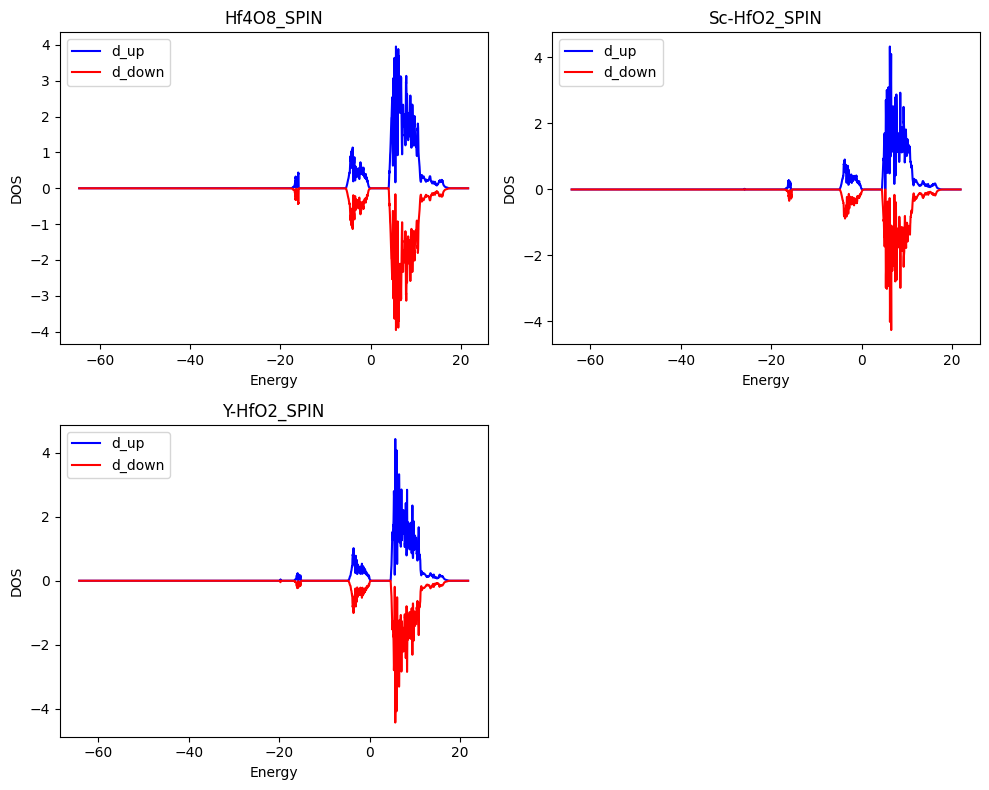

In [5]:
import math
import pandas as pd
import matplotlib.pyplot as plt

# 读取 CSV 文件
csv_file = "combined_pdos_side_by_side.csv"
df = pd.read_csv(csv_file)

# 获取所有列名，假定每个模型占3列
col_names = list(df.columns)
n_models = len(col_names) // 3

# 计算网格布局：尽量接近正方形
n_cols = math.ceil(math.sqrt(n_models))
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4), squeeze=False)

# 遍历每个模型
for i in range(n_models):
    # 每个模型对应三列：energy, d_up, d_down
    col_energy = col_names[i * 3]
    col_dup    = col_names[i * 3 + 1]
    col_ddown  = col_names[i * 3 + 2]
    
    # 提取模型名称（去掉后缀 _energy）
    model_name = col_energy.replace("_energy", "")
    
    # 将数据转换为数值（将空值转为 NaN）
    energy = pd.to_numeric(df[col_energy], errors='coerce')
    d_up   = pd.to_numeric(df[col_dup], errors='coerce')
    d_down = pd.to_numeric(df[col_ddown], errors='coerce')
    
    # 对应行中，energy 为 NaN 的行剔除（假设每个模型的三列数据应同时有效）
    valid = energy.notna()
    energy = energy[valid]
    d_up   = d_up[valid]
    d_down = d_down[valid]
    
    # 绘制图形
    ax = axes[i // n_cols][i % n_cols]
    ax.plot(energy, d_up, label="d_up", color="blue")
    ax.plot(energy, d_down, label="d_down", color="red")
    ax.set_title(model_name)
    ax.set_xlabel("Energy")
    ax.set_ylabel("DOS")
    ax.legend()

# 如果子图数多于模型数，则将多余的子图删除
total_axes = n_rows * n_cols
for j in range(n_models, total_axes):
    fig.delaxes(axes[j // n_cols][j % n_cols])

plt.tight_layout()
plt.show()
